### LunaSurface AI - Lunar Surface Hazard Terrain Segmentation with Self-Supervised Learning

#### Imports & Performance Setup

In [33]:
from sklearn.cluster import KMeans
import os
import time
import sys
import torch
import json
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pycocotools import mask as maskUtils

torch.set_float32_matmul_precision("medium")

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print("Using device:", DEVICE)

Using device: mps


#### Config

In [34]:
UNLABELED_DIR = "/Users/pheonix/Documents/Minor Project/LunaSurface-AI/Backend/Moon_Data/patches"


IMG_SIZE = 512
BATCH_SIZE = 6
EPOCHS_SSL = 1
EPOCHS_FINE = 80

NUM_CLASSES = 2
BLOCK_SIZE = 64
MASK_RATIO = 0.4

In [35]:
class UnlabeledDataset(Dataset):
    def __init__(self, folder, max_images=None, seed=42):
        self.paths = []

        # Collect all PNG image paths
        for root, _, files in os.walk(folder):
            for f in files:
                if f.lower().endswith(".png"):
                    self.paths.append(os.path.join(root, f))

        # 🔥 Random Subset Selection
        if max_images is not None:
            np.random.seed(seed)              # reproducible
            np.random.shuffle(self.paths)     # shuffle
            self.paths = self.paths[:max_images]

        print(f"✅ SSL Dataset Loaded: {len(self.paths)} images")

        self.tf = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.Grayscale(1),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx])
        return self.tf(img)


# 🔥 Choose how many images you want
MAX_SSL_IMAGES = 10000   # change this number anytime

unlabeled_dataset = UnlabeledDataset(
    UNLABELED_DIR,
    max_images=MAX_SSL_IMAGES,
    seed=42
)

unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

✅ SSL Dataset Loaded: 4186 images


In [36]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Stage 1 (512 → 256)
        self.stage1 = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Stage 2 (256 → 128)
        self.stage2 = nn.Sequential(
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Stage 3 (128 resolution)
        self.stage3 = nn.Sequential(
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1), nn.ReLU()
        )

    def forward(self,x):

        c1 = self.stage1(x)     # 256x256
        c2 = self.stage2(c1)    # 128x128
        c3 = self.stage3(c2)    # 128x128

        return c1, c2, c3

In [37]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(128,64,2,stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64,1,2,stride=2)
        )

    def forward(self,x):
        return self.model(x)

In [38]:
def block_mask(x, mask_ratio=MASK_RATIO, block_size=BLOCK_SIZE):

    B,C,H,W = x.shape
    x_masked = x.clone()

    num_blocks_h = H // block_size
    num_blocks_w = W // block_size
    total_blocks = num_blocks_h * num_blocks_w
    num_mask = int(total_blocks * mask_ratio)

    for b in range(B):
        perm = torch.randperm(total_blocks, device=x.device)[:num_mask]

        for idx in perm:
            row = idx // num_blocks_w
            col = idx % num_blocks_w

            h = row * block_size
            w = col * block_size

            x_masked[b,:,h:h+block_size,w:w+block_size] = 0

    return x_masked


In [39]:
import sys
import time

encoder = Encoder().to(DEVICE)
decoder = Decoder().to(DEVICE)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=1e-3
)

loss_fn_ssl = nn.MSELoss()

GREEN = "\033[92m"
RESET = "\033[0m"

for epoch in range(EPOCHS_SSL):

    encoder.train()
    decoder.train()

    start_time = time.time()
    total_loss = 0
    total_batches = len(unlabeled_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS_SSL}")

    for step, imgs in enumerate(unlabeled_loader):

        imgs = imgs.to(DEVICE)
        masked = block_mask(imgs)

        _, _, feats = encoder(masked)
        recon = decoder(feats)

        loss = loss_fn_ssl(recon, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        progress = (step + 1) / total_batches
        percent = progress * 100

        bar_length = 30
        filled = int(bar_length * progress)

        # 🔥 Double line style
        bar = "=" * filled + " " * (bar_length - filled)

        sys.stdout.write(
            f"\r{GREEN}[{bar}] {percent:6.2f}% | loss: {loss.item():.4f}{RESET}"
        )
        sys.stdout.flush()

    epoch_time = time.time() - start_time
    avg_loss = total_loss / total_batches

    print(f"\nCompleted in {epoch_time:.0f}s "
          f"- Avg loss: {avg_loss:.4f}")


Epoch 1/1
[==============================] 100.00% | loss: 0.0074
Completed in 371s - Avg loss: 0.0078


In [40]:
torch.save(encoder.state_dict(), "ssl_encoder_advanced.pth")
print("SSL Encoder Saved")

SSL Encoder Saved


In [41]:
encoder = Encoder().to(DEVICE)
encoder.load_state_dict(torch.load("ssl_encoder_advanced.pth"))

for p in encoder.parameters():
    p.requires_grad = True


for p in encoder.stage3.parameters():
    p.requires_grad = True

In [42]:
def ssl_segmentation_output(encoder, image_path):

    encoder.eval()

    tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(1),
        transforms.ToTensor()
    ])

    img = Image.open(image_path).convert("L")
    img_tensor = tf(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        _, _, c3 = encoder(img_tensor)

    feats = c3[0].cpu().numpy()

    C, H, W = feats.shape
    feats = feats.reshape(C, -1).T

    kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
    labels = kmeans.fit_predict(feats)

    seg = labels.reshape(H, W)

    seg = Image.fromarray(seg.astype(np.uint8))
    seg = seg.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

    return img_tensor.cpu(), np.array(seg)

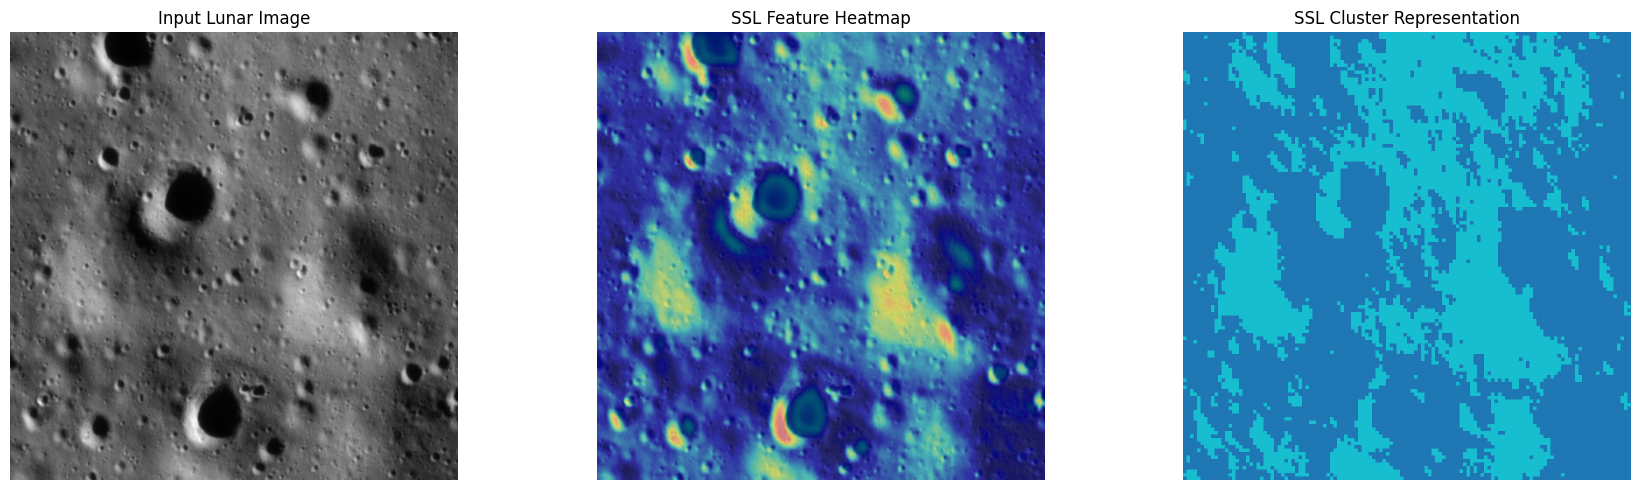

In [43]:
# ==========================================
# 🔥 Stage 1 SSL Demo Visualization
# ==========================================

sample_image_path = "/Users/pheonix/Documents/Minor Project/LunaSurface-AI/Backend/Moon_Data/patches/ohr_000/ohr_000_patch_0053.png"

from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

encoder.eval()

tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(1),
    transforms.ToTensor()
])

img = Image.open(sample_image_path).convert("L")
img_tensor = tf(img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    c1, c2, c3 = encoder(img_tensor)

# ---------------------------------
# Feature Heatmap
# ---------------------------------
feat = c3[0].mean(dim=0).cpu().numpy()

feat = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8)

feat_up = Image.fromarray((feat * 255).astype(np.uint8))
feat_up = feat_up.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
feat_up = np.array(feat_up)

# ---------------------------------
# Cluster Map
# ---------------------------------
f = c3[0].cpu().numpy()

C,H,W = f.shape
X = f.reshape(C, -1).T

kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
labels = kmeans.fit_predict(X)

cluster = labels.reshape(H, W)

cluster = Image.fromarray(cluster.astype(np.uint8))
cluster = cluster.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
cluster = np.array(cluster)

# ---------------------------------
# Plot
# ---------------------------------
plt.figure(figsize=(18,5))

# Input
plt.subplot(1,3,1)
plt.imshow(img_tensor[0,0].cpu(), cmap="gray")
plt.title("Input Lunar Image")
plt.axis("off")

# Feature heatmap
plt.subplot(1,3,2)
plt.imshow(img_tensor[0,0].cpu(), cmap="gray")
plt.imshow(feat_up, cmap="jet", alpha=0.45)
plt.title("SSL Feature Heatmap")
plt.axis("off")

# Cluster map
plt.subplot(1,3,3)
plt.imshow(cluster, cmap="tab10")
plt.title("SSL Cluster Representation")
plt.axis("off")

plt.tight_layout()
plt.show()


In [44]:
COCO_JSON = "/Users/pheonix/Documents/Minor Project/LunaSurface-AI/Backend/Moon_Data/1.LabeledDataset/Lunar.coco-segmentation/train/_annotations.coco.json"

COCO_IMG_DIR = "/Users/pheonix/Documents/Minor Project/LunaSurface-AI/Backend/Moon_Data/1.LabeledDataset/Lunar.coco-segmentation/train"

NUM_CLASSES = 2   # background + crater


class CocoCraterDataset(Dataset):
    def __init__(self, json_path, img_dir):

        self.img_dir = img_dir

        with open(json_path, "r") as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]
        self.annotations = self.coco["annotations"]

        self.ann_map = {}

        for ann in self.annotations:
            img_id = ann["image_id"]
            if img_id not in self.ann_map:
                self.ann_map[img_id] = []
            self.ann_map[img_id].append(ann)

        self.tf = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.Grayscale(1),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        info = self.images[idx]

        img_path = os.path.join(self.img_dir, info["file_name"])
        img = Image.open(img_path).convert("L")
        img_tensor = self.tf(img)

        mask = np.zeros((info["height"], info["width"]), dtype=np.uint8)

        anns = self.ann_map.get(info["id"], [])

        for ann in anns:
            binary = maskUtils.decode(ann["segmentation"])
            mask[binary == 1] = 1   # crater only

        mask = Image.fromarray(mask)
        mask = mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

        mask = torch.tensor(np.array(mask)).long()

        return img_tensor, mask


dataset_full = CocoCraterDataset(COCO_JSON, COCO_IMG_DIR)

train_size = int(0.8 * len(dataset_full))
val_size = len(dataset_full) - train_size

train_set, val_set = random_split(dataset_full, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE)


In [45]:
class MultiScaleSegModel(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

        # Final fusion head
        self.fusion = nn.Sequential(
            nn.Conv2d(32 + 64 + 128, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, NUM_CLASSES, 1)
        )

    def forward(self,x):

        c1, c2, c3 = self.encoder(x)

        # Upsample lower resolution maps
        c2_up = F.interpolate(c2, size=c1.shape[2:], mode="bilinear", align_corners=False)
        c3_up = F.interpolate(c3, size=c1.shape[2:], mode="bilinear", align_corners=False)

        # Concatenate multi-scale features
        fused = torch.cat([c1, c2_up, c3_up], dim=1)

        mask = self.fusion(fused)

        # Final upsample to original size
        mask = F.interpolate(
            mask,
            size=(IMG_SIZE, IMG_SIZE),
            mode="bilinear",
            align_corners=False
        )

        return mask

seg_model = MultiScaleSegModel(encoder).to(DEVICE)


In [46]:
weights = torch.tensor([1.0, 1.5]).to(DEVICE)
ce_loss = nn.CrossEntropyLoss(weight=weights)

def dice_loss(pred, target, eps=1e-6):

    pred = F.softmax(pred, dim=1)
    target_onehot = F.one_hot(target, NUM_CLASSES).permute(0,3,1,2).float()

    intersection = (pred * target_onehot).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target_onehot.sum(dim=(2,3))

    dice = (2*intersection + eps) / (union + eps)

    return 1 - dice.mean()

optimizer = torch.optim.Adam(
    list(seg_model.fusion.parameters()) +
    list(encoder.stage3.parameters()),
    lr=1e-4
)


In [47]:
for epoch in range(EPOCHS_FINE):

    seg_model.fusion.train()
    encoder.eval()
    train_loss = 0

    for imgs, masks in train_loader:

        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        preds = seg_model(imgs)

        loss = ce_loss(preds, masks) + dice_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # validation
    seg_model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, masks in val_loader:

            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            preds = seg_model(imgs)

            loss = ce_loss(preds, masks) + dice_loss(preds, masks)
            val_loss += loss.item()

    print(f"Epoch {epoch} Train {train_loss/len(train_loader)} Val {val_loss/len(val_loader)}")

Epoch 0 Train 1.142971897125244 Val 1.0329506397247314
Epoch 1 Train 0.9987547278404236 Val 0.970270425081253
Epoch 2 Train 0.9266618371009827 Val 0.9153330028057098
Epoch 3 Train 0.8693617820739746 Val 0.8579045832157135
Epoch 4 Train 0.8186080813407898 Val 0.7977266609668732
Epoch 5 Train 0.7727315783500671 Val 0.7477598190307617
Epoch 6 Train 0.7795131921768188 Val 0.7190849483013153
Epoch 7 Train 0.7321879625320434 Val 0.708724170923233
Epoch 8 Train 0.6820363759994507 Val 0.6872574687004089
Epoch 9 Train 0.68838871717453 Val 0.6717279553413391
Epoch 10 Train 0.6513530850410462 Val 0.6727588474750519
Epoch 11 Train 0.6560380458831787 Val 0.6637582182884216
Epoch 12 Train 0.6868053793907165 Val 0.6453585028648376
Epoch 13 Train 0.6793395161628724 Val 0.6543684005737305
Epoch 14 Train 0.6462008118629455 Val 0.6284399926662445
Epoch 15 Train 0.6436096251010894 Val 0.6415204405784607
Epoch 16 Train 0.6374491572380065 Val 0.669480174779892
Epoch 17 Train 0.6285176992416381 Val 0.6260350

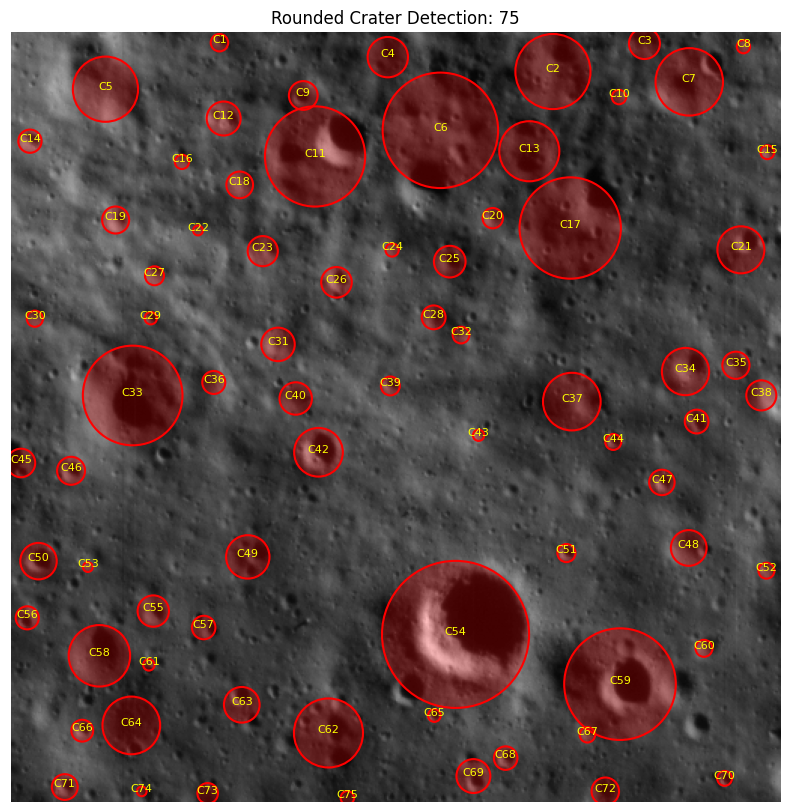

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from matplotlib.patches import Circle

seg_model.eval()

img, mask = next(iter(val_loader))
img = img.to(DEVICE)

with torch.no_grad():
    pred = seg_model(img)
    pred_class = torch.argmax(F.softmax(pred, dim=1), dim=1)

img_np = img[0,0].cpu().numpy()
pred_np = pred_class[0].cpu().numpy()

# crater class = 1
binary = (pred_np == 1).astype(np.uint8)

# label regions
labeled, num = ndimage.label(binary)

fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(img_np, cmap="gray")

count = 0

for i in range(1, num + 1):

    ys, xs = np.where(labeled == i)

    area = len(xs)

    # remove tiny noise
    if area < 30:
        continue

    cx = xs.mean()
    cy = ys.mean()

    # estimate radius from area
    radius = np.sqrt(area / np.pi)

    # draw round crater
    circ = Circle(
      (cx, cy),
      radius,
      edgecolor="red",
      facecolor=(1, 0, 0, 0.25),  # RGBA: red with 25% opacity
      linewidth=1.5
)
    ax.add_patch(circ)

    count += 1

    ax.text(
        cx, cy,
        f"C{count}",
        color="yellow",
        fontsize=8,
        ha="center"
    )

ax.set_title(f"Rounded Crater Detection: {count}")
ax.axis("off")
plt.show()

In [49]:
seg_model.eval()

total_iou         = []
total_dice        = []
total_precision   = []
total_recall      = []
total_f1          = []
total_specificity = []
total_count_error = []
eps = 1e-6

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds       = seg_model(imgs)
        pred_class  = torch.argmax(F.softmax(preds, dim=1), dim=1)

        for b in range(imgs.size(0)):
            gt = masks[b]
            pr = pred_class[b]

            gt_bin = (gt == 1)
            pr_bin = (pr == 1)

            TP = (gt_bin  &  pr_bin).sum().item()
            FP = (~gt_bin &  pr_bin).sum().item()
            FN = (gt_bin  & ~pr_bin).sum().item()
            TN = (~gt_bin & ~pr_bin).sum().item()

            iou         = TP / (TP + FP + FN + eps)
            dice        = (2 * TP) / (2 * TP + FP + FN + eps)
            precision   = TP / (TP + FP + eps)
            recall      = TP / (TP + FN + eps)
            f1          = (2 * precision * recall) / (precision + recall + eps)
            specificity = TN / (TN + FP + eps)

            gt_count    = ndimage.label(gt_bin.cpu().numpy())[1]
            pr_count    = ndimage.label(pr_bin.cpu().numpy())[1]
            count_error = abs(gt_count - pr_count)

            total_iou.append(iou)
            total_dice.append(dice)
            total_precision.append(precision)
            total_recall.append(recall)
            total_f1.append(f1)
            total_specificity.append(specificity)
            total_count_error.append(count_error)

print("\n╔══════════════════════════════════╗")
print("║   FINAL VALIDATION METRICS       ║")
print("╠══════════════════════════════════╣")
print(f"║  mIoU        : {np.mean(total_iou)*100:6.2f}%           ║")
print(f"║  Dice Score  : {np.mean(total_dice)*100:6.2f}%           ║")
print(f"║  Precision   : {np.mean(total_precision)*100:6.2f}%           ║")
print(f"║  Recall      : {np.mean(total_recall)*100:6.2f}%           ║")
print(f"║  F1 Score    : {np.mean(total_f1)*100:6.2f}%           ║")
print(f"║  Specificity : {np.mean(total_specificity)*100:6.2f}%           ║")
print(f"║  Count Error : {np.mean(total_count_error):6.2f} craters    ║")
print("╚══════════════════════════════════╝")


╔══════════════════════════════════╗
║   FINAL VALIDATION METRICS       ║
╠══════════════════════════════════╣
║  mIoU        :  49.51%           ║
║  Dice Score  :  65.86%           ║
║  Precision   :  64.72%           ║
║  Recall      :  69.99%           ║
║  F1 Score    :  65.86%           ║
║  Specificity :  89.81%           ║
║  Count Error :  33.43 craters    ║
╚══════════════════════════════════╝


In [50]:
torch.save(seg_model.state_dict(),
           "lunar_ssl_segmentation_advanced.pth")

print("Final Model Saved")

Final Model Saved


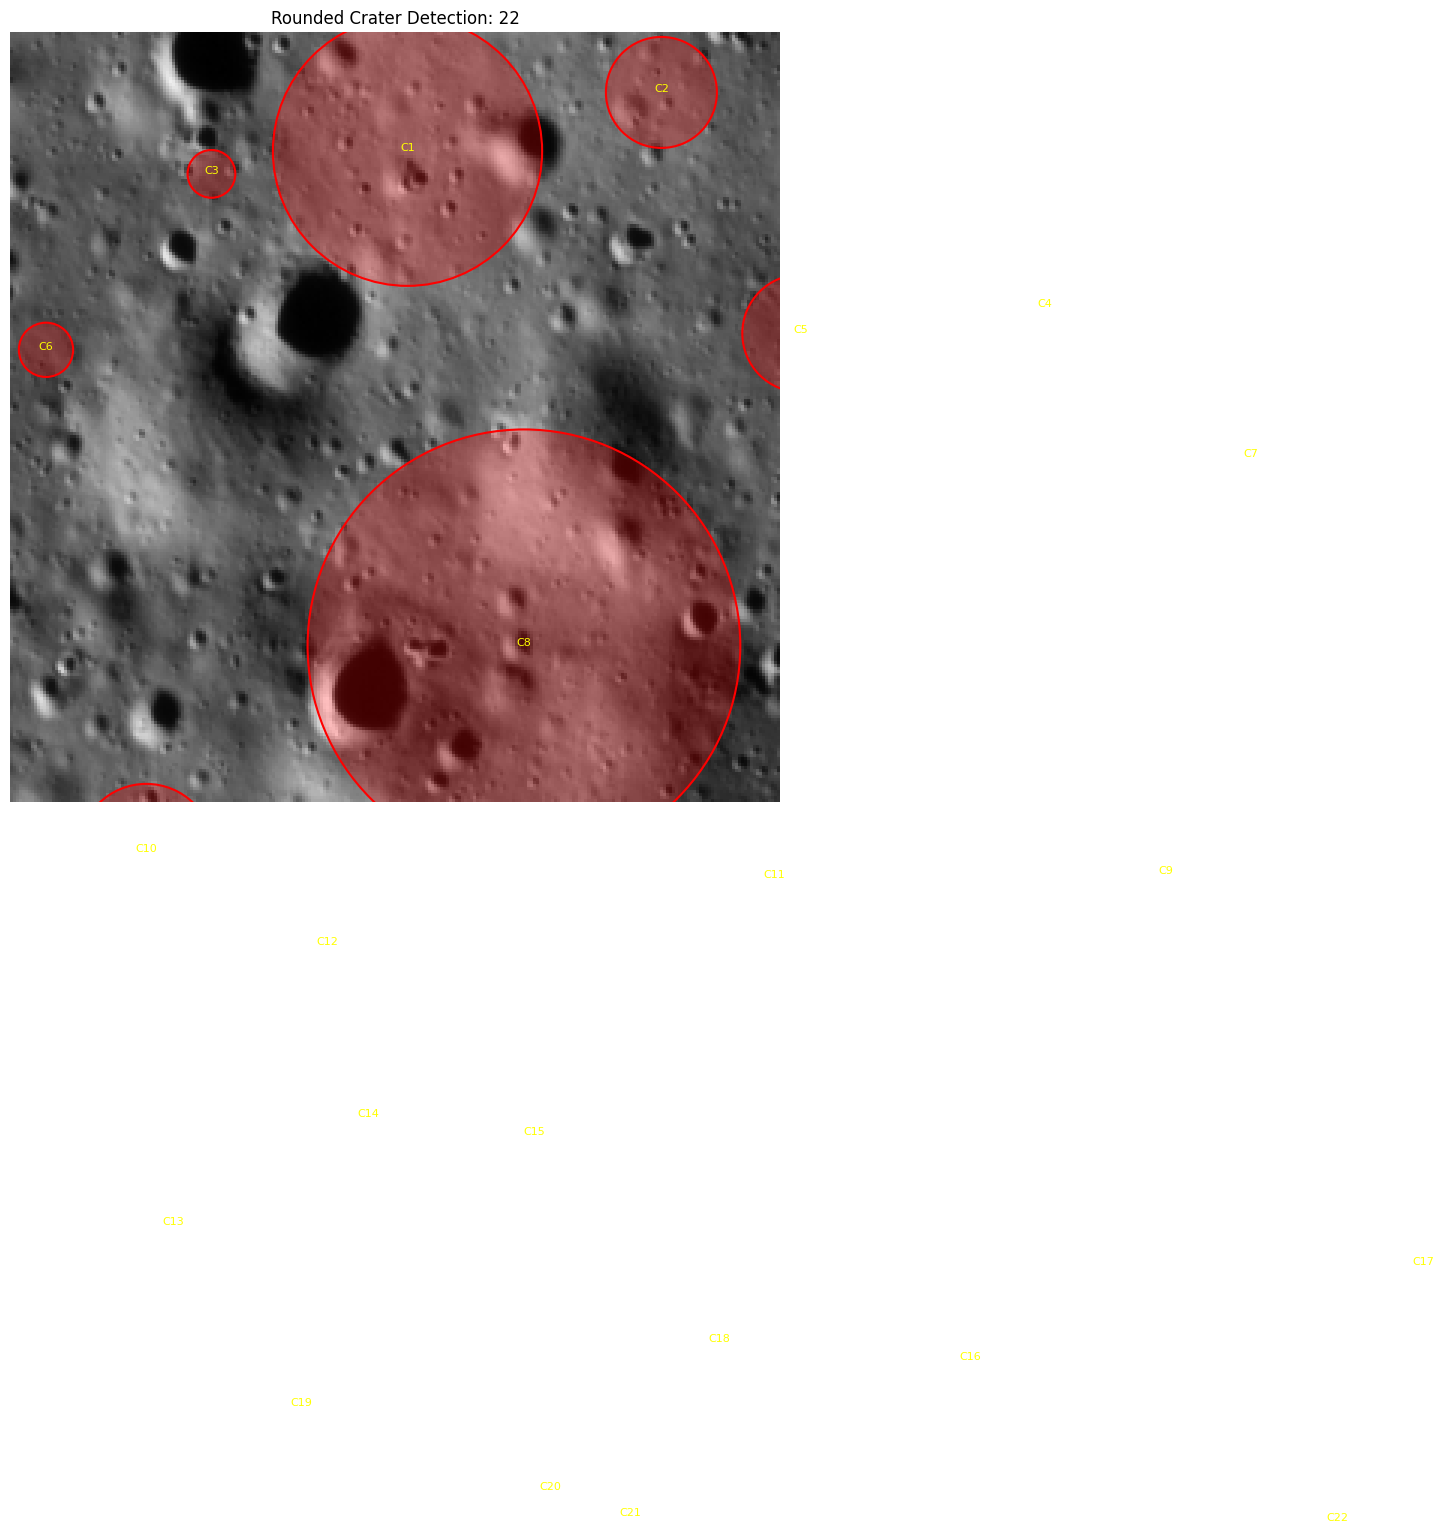

In [52]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from matplotlib.patches import Circle
from PIL import Image
from torchvision import transforms

# ----------------------------
# 1. Load your trained model
# ----------------------------
seg_model.load_state_dict(torch.load("lunar_ssl_segmentation_advanced.pth", map_location=DEVICE))
seg_model.to(DEVICE)
seg_model.eval()

# ----------------------------
# 2. Load your own sample image
# ----------------------------
img_path = "/Users/pheonix/Documents/Minor Project/LunaSurface-AI/Backend/Moon_Data/patches/ohr_000/ohr_000_patch_0053.png"   # change to your image name

img_pil = Image.open(img_path).convert("L")   # grayscale

# same size as training
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

# ----------------------------
# 3. Predict
# ----------------------------
with torch.no_grad():
    pred = seg_model(img_tensor)
    pred_class = torch.argmax(F.softmax(pred, dim=1), dim=1)

# ----------------------------
# 4. Convert to numpy
# ----------------------------
img_np = img_tensor[0,0].cpu().numpy()
pred_np = pred_class[0].cpu().numpy()

# crater class = 1
binary = (pred_np == 1).astype(np.uint8)

# ----------------------------
# 5. Detect crater regions
# ----------------------------
labeled, num = ndimage.label(binary)

fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(img_np, cmap="gray")

count = 0

for i in range(1, num + 1):

    ys, xs = np.where(labeled == i)
    area = len(xs)

    # remove tiny noise
    if area < 30:
        continue

    cx = xs.mean()
    cy = ys.mean()

    radius = np.sqrt(area / np.pi)

    circ = Circle(
        (cx, cy),
        radius,
        edgecolor="red",
        facecolor=(1, 0, 0, 0.25),
        linewidth=1.5
    )

    ax.add_patch(circ)

    count += 1

    ax.text(
        cx, cy,
        f"C{count}",
        color="yellow",
        fontsize=8,
        ha="center"
    )

# ----------------------------
# 6. Show output
# ----------------------------
ax.set_title(f"Rounded Crater Detection: {count}")
ax.axis("off")
plt.show()